# Milestone 4: Evaluation of LLM Prompting Strategies

This notebook evaluates how different prompting strategies affected an
LLM's explanation of similarity among synthetic patient records.

Four prompting methods are compared:

1. Zero-shot prompting
2. Few-shot / in-context learning
3. Chain-of-Thought-style structured reasoning
4. Tree-of-Thought-style multi-perspective reasoning

Because no clinician-authored reference explanation is available, the
generated responses are evaluated using a transparent rubric grounded
in the synthetic patient records and the known patient-retrieval
algorithm.

The evaluation focuses on factual accuracy, completeness, retrieval
faithfulness, clinical relevance, and clarity.

## 1. Project Setup

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

### Load Prompting Results

In [2]:
import pandas as pd

results_df = pd.read_csv(
    PROJECT_ROOT / "outputs" / "prompt_results.csv"
)

results_df

,METHOD,PROMPT,RESPONSE
0,Zero-shot,\nYou are analyzing synthetic patient records ...,### Major clinical similarities\n\n- All four ...
1,Few-shot,\nYou are analyzing synthetic patient records ...,### Similar Patient 1\n\n**Major similarities*...
2,Chain-of-Thought,\nYou are analyzing synthetic patient records ...,### Step 1: Demographics\n\n- **Query patient:...
3,Tree-of-Thought,\nYou are analyzing synthetic patient records ...,## Perspective A — Clinical Conditions\n\n**St...


### Import Functions

In [3]:
from src.evaluation import (
    EVALUATION_CRITERIA,
    validate_scores,
    create_evaluation_table,
    calculate_response_lengths
)

## 2. Define the Scoring Scale

### Evaluation Rubric

Each response is scored from **1 (poor) to 5 (excellent)** on five
criteria.

#### Factual Accuracy
Measures whether claims are supported by the supplied synthetic patient
records.

#### Completeness
Measures whether the response identifies the major similarities and
important differences among patients.

### Retrieval Faithfulness
Measures whether the response correctly distinguishes features used by
the retrieval system from descriptive attributes that did not affect
retrieval.

#### Clinical Relevance
Measures whether the response prioritizes meaningful clinical evidence,
particularly shared conditions and healthcare-utilization information.

#### Clarity and Organization
Measures whether the explanation is structured, understandable, and easy
to trace back to the patient records.

The maximum possible score is **25 points**. All criteria are weighted
equally.

In [4]:
scores = {
    "Zero-shot": {
        "FACTUAL_ACCURACY": 5,
        "COMPLETENESS": 4,
        "RETRIEVAL_FAITHFULNESS": 5,
        "CLINICAL_RELEVANCE": 5,
        "CLARITY_ORGANIZATION": 4,
        "EVIDENCE_PRIORITIZATION": 4
    },

    "Few-shot": {
        "FACTUAL_ACCURACY": 5,
        "COMPLETENESS": 5,
        "RETRIEVAL_FAITHFULNESS": 5,
        "CLINICAL_RELEVANCE": 5,
        "CLARITY_ORGANIZATION": 5,
        "EVIDENCE_PRIORITIZATION": 4
    },

    "Chain-of-Thought": {
        "FACTUAL_ACCURACY": 5,
        "COMPLETENESS": 5,
        "RETRIEVAL_FAITHFULNESS": 5,
        "CLINICAL_RELEVANCE": 5,
        "CLARITY_ORGANIZATION": 5,
        "EVIDENCE_PRIORITIZATION": 4
    },

    "Tree-of-Thought": {
        "FACTUAL_ACCURACY": 5,
        "COMPLETENESS": 5,
        "RETRIEVAL_FAITHFULNESS": 5,
        "CLINICAL_RELEVANCE": 5,
        "CLARITY_ORGANIZATION": 5,
        "EVIDENCE_PRIORITIZATION": 5
    },
}

### Generate the Tables

In [5]:
validate_scores(scores)

evaluation_df = create_evaluation_table(
    scores
)

evaluation_df

,METHOD,FACTUAL_ACCURACY,COMPLETENESS,RETRIEVAL_FAITHFULNESS,CLINICAL_RELEVANCE,CLARITY_ORGANIZATION,EVIDENCE_PRIORITIZATION,TOTAL_SCORE,AVERAGE_SCORE
0,Zero-shot,5,4,5,5,4,4,27,4.500000
1,Few-shot,5,5,5,5,5,4,29,4.833333
2,Chain-of-Thought,5,5,5,5,5,4,29,4.833333
3,Tree-of-Thought,5,5,5,5,5,5,30,5.000000


These scores represent a structured qualitative evaluation rather than
a validated clinical benchmark. They are intended to support comparison
of prompting behavior within this tutorial and should not be interpreted
as measures of real-world clinical performance.

### Evaluation Results

All four prompting strategies performed strongly, with average rubric
scores ranging from 4.50 to 5.00 out of 5.

**Zero-shot prompting** achieved a total score of 27/30. The response
was factually accurate, clinically relevant, and faithful to the
retrieval method, but it was less systematic in its organization and
coverage than the structured prompting approaches.

**Few-shot prompting** improved the score to 29/30. In-context examples
encouraged a consistent patient-by-patient comparison and improved the
completeness and organization of the response.

**Chain-of-Thought-style prompting** also achieved 29/30. Its sequential
analysis made the comparison transparent and comprehensive across
demographics, clinical conditions, medications, and healthcare
utilization.

**Tree-of-Thought-style prompting** received the highest score at 30/30.
Its primary advantage was evidence prioritization: the response
explicitly identified clinical-condition overlap as the strongest
evidence, treated age and gender as supporting evidence, and correctly
recognized medication history as descriptive rather than a retrieval
feature.

Overall, structured prompting produced modest improvements over the
zero-shot baseline. The primary benefit was not the discovery of new
clinical facts, but improved organization, completeness, transparency,
and prioritization of evidence.

### 3. Add Classification Consistency

In [6]:
classification_df = pd.DataFrame(
    {
        "PATIENT": [
            "Similar Patient 1",
            "Similar Patient 2",
            "Similar Patient 3",
        ],

        "COSINE_SIMILARITY": [
            0.999940,
            0.994404,
            0.994206,
        ],

        "LLM_CLASSIFICATION": [
            "HIGH",
            "HIGH",
            "HIGH",
        ],
    }
)

classification_df

,PATIENT,COSINE_SIMILARITY,LLM_CLASSIFICATION
0,Similar Patient 1,0.999940,HIGH
1,Similar Patient 2,0.994404,HIGH
2,Similar Patient 3,0.994206,HIGH


### Downstream Classification Evaluation

The few-shot classification experiment assigned all three retrieved
patients to the **HIGH similarity** category.

All three patients also had cosine similarity scores greater than 0.99.
Therefore, the LLM's qualitative classifications were consistent with
the retrieval system's numerical similarity results.

This should not be interpreted as classification accuracy because no
independent ground-truth HIGH/MODERATE/LOW labels were available.
Instead, the result demonstrates consistency between the numerical
retrieval method and the LLM's downstream qualitative classification.

## 4. Save the Tables

In [7]:
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

evaluation_df.to_csv(
    TABLE_DIR / "prompt_evaluation.csv",
    index=False,
)

classification_df.to_csv(
    TABLE_DIR / "classification_consistency.csv",
    index=False,
)

## 5. Count Word Length for Each Response

In [8]:
responses = dict(
    zip(
        results_df["METHOD"],
        results_df["RESPONSE"],
    )
)

response_length_df = calculate_response_lengths(
    responses
)

response_length_df

,METHOD,WORD_COUNT
0,Zero-shot,242
1,Few-shot,318
2,Chain-of-Thought,286
3,Tree-of-Thought,517


### Response Length Analysis

Prompting strategy affected not only response quality but also response
length.

Zero-shot prompting produced the shortest response at **242 words**.
Few-shot prompting increased the response to **318 words**, while
Chain-of-Thought-style prompting produced a similarly detailed analysis
in **286 words**.

Tree-of-Thought-style prompting generated the longest response at
**517 words**, more than twice the length of the zero-shot response.
Although Tree-of-Thought received the highest evaluation score, its
improvement over Few-shot and Chain-of-Thought was small relative to
the increase in response length.

These results demonstrate a trade-off between explanatory depth and
conciseness. Tree-of-Thought provided the strongest evidence
prioritization and most comprehensive analysis, while Chain-of-Thought
provided a strong balance between evaluation quality and response
length.

## 6. Visualization

### Prompt Evaluation Scores

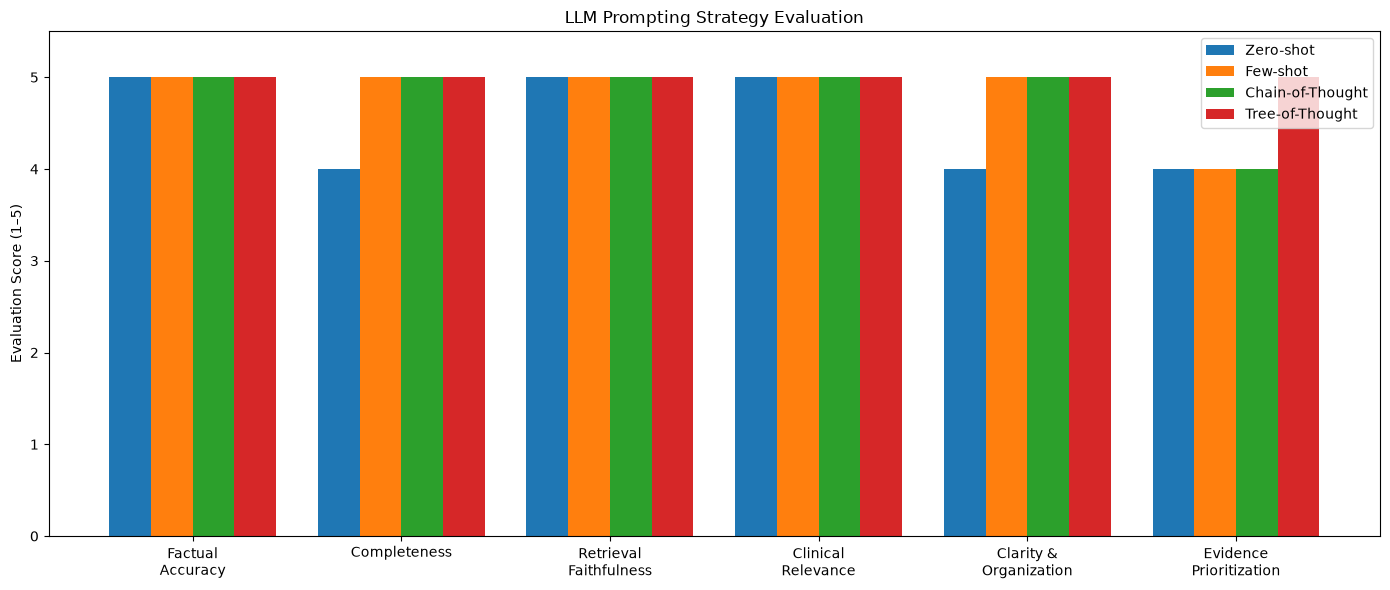

In [10]:
import matplotlib.pyplot as plt
import numpy as np

criteria = [
    "FACTUAL_ACCURACY",
    "COMPLETENESS",
    "RETRIEVAL_FAITHFULNESS",
    "CLINICAL_RELEVANCE",
    "CLARITY_ORGANIZATION",
    "EVIDENCE_PRIORITIZATION",
]

methods = evaluation_df["METHOD"].tolist()

x = np.arange(len(criteria))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

for i, method in enumerate(methods):
    values = (
        evaluation_df.loc[
            evaluation_df["METHOD"] == method,
            criteria
        ]
        .iloc[0]
        .values
        .astype(float)
    )

    ax.bar(
        x + i * width,
        values,
        width,
        label=method,
    )

ax.set_ylabel("Evaluation Score (1–5)")
ax.set_title("LLM Prompting Strategy Evaluation")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(
    [
        "Factual\nAccuracy",
        "Completeness",
        "Retrieval\nFaithfulness",
        "Clinical\nRelevance",
        "Clarity &\nOrganization",
        "Evidence\nPrioritization",
    ]
)

ax.set_ylim(0, 5.5)
ax.legend()

plt.tight_layout()
plt.show()

#### Save Evaluation

In [11]:
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(
    FIGURE_DIR / "prompt_evaluation.png",
    dpi=300,
    bbox_inches="tight",
)

### Quality vs. Response Length

#### Combine the Dataset then Visualize

In [12]:
tradeoff_df = evaluation_df[
    ["METHOD", "AVERAGE_SCORE"]
].merge(
    response_length_df,
    on="METHOD",
)

tradeoff_df

,METHOD,AVERAGE_SCORE,WORD_COUNT
0,Zero-shot,4.500000,242
1,Few-shot,4.833333,318
2,Chain-of-Thought,4.833333,286
3,Tree-of-Thought,5.000000,517


In [15]:
tradeoff_df.to_csv(
    TABLE_DIR / "quality_length_tradeoff.csv",
    index=False,
)

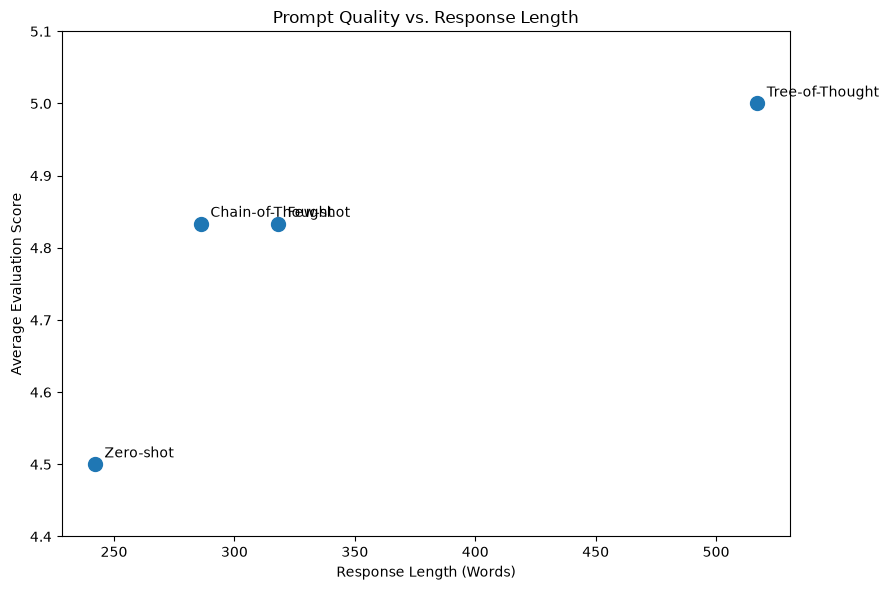

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    tradeoff_df["WORD_COUNT"],
    tradeoff_df["AVERAGE_SCORE"],
    s=100,
)

for _, row in tradeoff_df.iterrows():
    ax.annotate(
        row["METHOD"],
        (
            row["WORD_COUNT"],
            row["AVERAGE_SCORE"],
        ),
        xytext=(7, 5),
        textcoords="offset points",
    )

ax.set_xlabel("Response Length (Words)")
ax.set_ylabel("Average Evaluation Score")
ax.set_title("Prompt Quality vs. Response Length")

ax.set_ylim(4.4, 5.1)

plt.tight_layout()
plt.show()

#### Save Image

In [14]:
fig.savefig(
    FIGURE_DIR / "quality_vs_response_length.png",
    dpi=300,
    bbox_inches="tight",
)